In [12]:
import numpy as np
import matplotlib.pyplot as plt
import copy
from scipy.signal import detrend

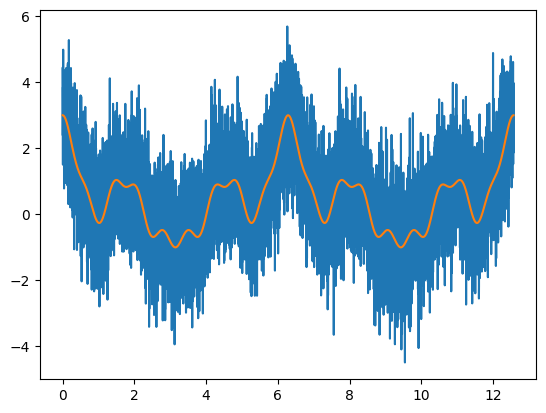

In [13]:
N = 10001
time = np.linspace(0,4*np.pi,N)

signal = np.zeros(N)

for j in range(1,4):
  signal += np.cos(j*time)**j

noisysignal = signal + np.random.randn(N)

plt.plot(time,noisysignal, time,signal)
plt.show()

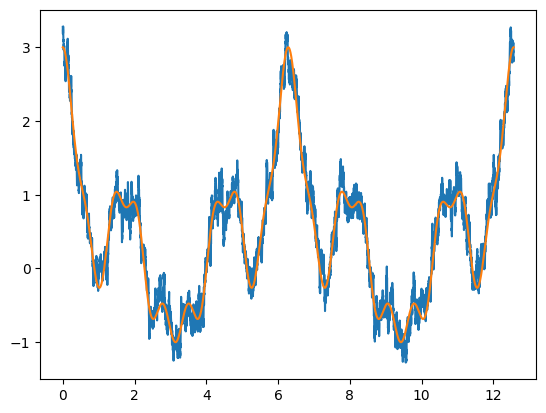

In [14]:
# Mean Smoothing Filter
filtered_signal = copy.deepcopy(noisysignal)

k = 15

for t in range(N):
  lower_bound = np.max((0,t-k))
  upper_bound = np.min((N,t+k))
  filtered_signal[t] = np.mean(noisysignal[lower_bound:upper_bound])

plt.plot(time,filtered_signal, time,signal)
plt.show()

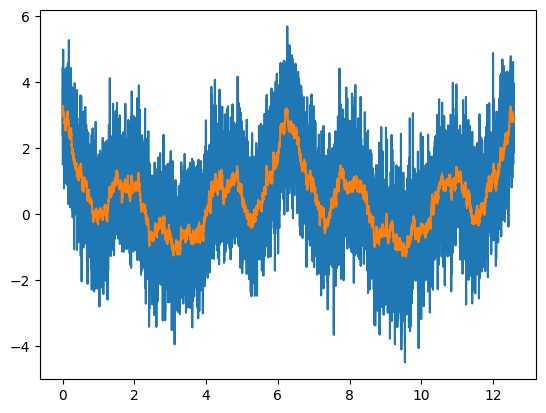

In [15]:
plt.plot(time, noisysignal, time, filtered_signal)

In [16]:
def mean_smooth(signalIn, k):
  filtered_signal = copy.deepcopy(signalIn)

  for t in range(N):
    filtered_signal[t] = np.mean(noisysignal[np.max((0,t-k)):np.min((N,t+k))])
  return filtered_signal

k_values = np.arange(5, 41)
signal_corrs = []


for k_index in k_values:
  # filter the signal
  f_signal = mean_smooth(noisysignal, k_index)

  # compute the correlation signal and original
  signal_corrs.append(np.corrcoef(f_signal, signal)[0, 1])

In [17]:
signal_corrs

[np.float64(0.951049263444924),
 np.float64(0.958906558421215),
 np.float64(0.9645841406798589),
 np.float64(0.9689636531679201),
 np.float64(0.9723574437123281),
 np.float64(0.9750566604261935),
 np.float64(0.9772770538028636),
 np.float64(0.9791065900623738),
 np.float64(0.9806715951865131),
 np.float64(0.9819940956834072),
 np.float64(0.9831355361212953),
 np.float64(0.9841148002261269),
 np.float64(0.9849714352765095),
 np.float64(0.9857525942561869),
 np.float64(0.986448713588236),
 np.float64(0.9870546221156147),
 np.float64(0.9875879623362354),
 np.float64(0.9880837757808474),
 np.float64(0.9885434372165794),
 np.float64(0.9889768119913342),
 np.float64(0.9893712631184343),
 np.float64(0.9897478753749819),
 np.float64(0.9900890126298157),
 np.float64(0.9904115575065124),
 np.float64(0.9907132214366077),
 np.float64(0.991004647173474),
 np.float64(0.991290116825427),
 np.float64(0.9915595983464521),
 np.float64(0.9918098541310658),
 np.float64(0.9920449012952485),
 np.float64(0.9

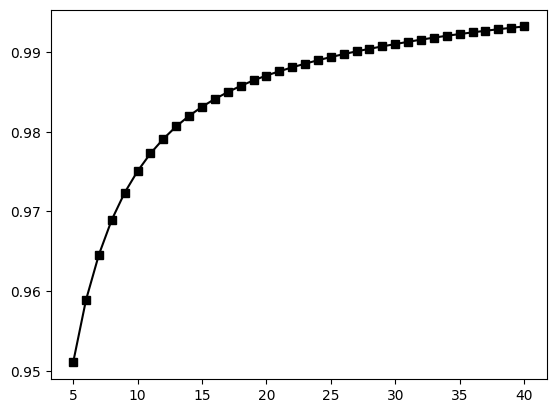

In [18]:
plt.plot(k_values, signal_corrs, 'ks-')

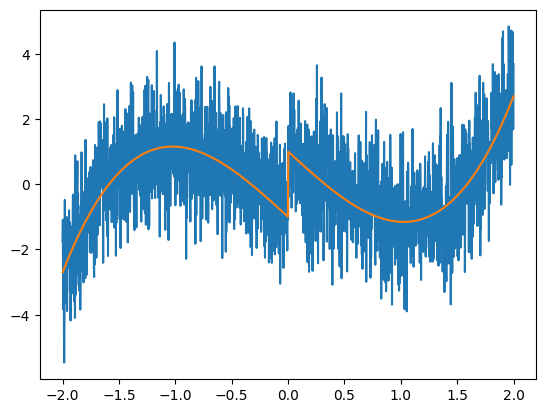

In [19]:
# Smooth via Gaussian Convoltion
# create signal

srate = 512
time = np.arange(-2, 2 + 1 / srate, 1 / srate)
points = len(time)

signal = detrend(time**3 + np.sign(time))
noisysignal = signal + np.random.randn(points) * 1.1

plt.plot(time, noisysignal, time, signal)

Text(0.5, 1.0, 'n=21, s=0.005')

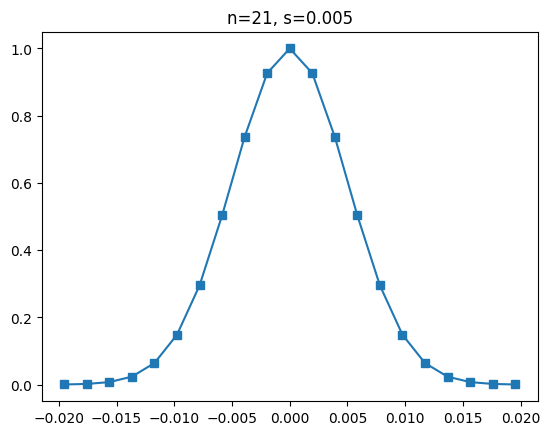

In [20]:
# Create the Gaussian
k = 10
x = np.arange(-k, k + 1) / srate
s = 0.005

gkern = np.exp(-x**2 / (2 * s**2))

plt.plot(x, gkern, 's-')
plt.title('n=%s, s=%g'%(2 * k + 1, s))

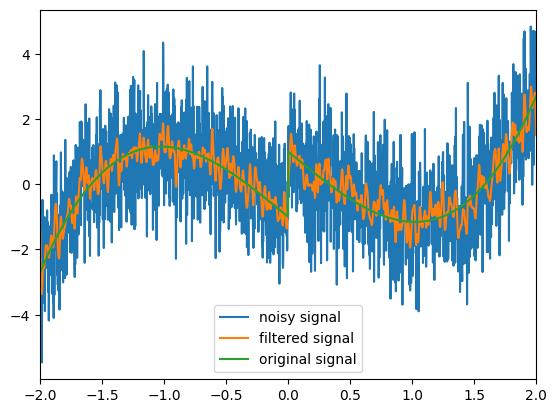

In [21]:
# Gaussian smoothing filter

gkern /= sum(gkern)

filtered_signal = np.convolve(noisysignal, gkern, mode='same')

plt.plot(time, noisysignal, time, filtered_signal, time, signal)
plt.legend(['noisy signal', 'filtered signal', 'original signal'])
plt.xlim(time[[0,-1]])
plt.show()

## Gaussian Kernel Sweeping & Signal Denoising

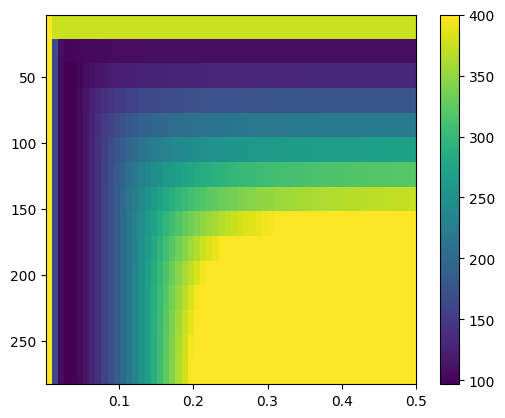

In [33]:
# Demo 1: SSE Grid Over (k, σ) = Global Behaviour

#define the parameter ranges
krange = np.arange(3,303,20)
srange = np.linspace(0.001, 0.5, 60)

# initialise some output variables
sseMat = np.zeros((len(krange), len(srange)))

# double loop over the two parameters
for ki in range(len(krange)):
  for si in range(len(srange)):
    #create a gaussian
    x  = np.arange(-krange[ki], krange[ki]+1)/srate
    gkern = np.exp(-x**2/(2*srange[si]**2))

    #filter the signal via convolution
    filtsig = np.convolve(noisysignal, gkern/sum(gkern), mode='same')

    # compute the SSE (Sum of Squared Errors)
    sseMat[ki,si] = np.sum((filtsig-signal)**2)


# plotting
plt.imshow(sseMat, vmax=400,
           extent=[srange[0],srange[-1],krange[-1],krange[0]])
plt.gca().set_aspect(1/plt.gca().get_data_ratio())
plt.colorbar()
plt.show()

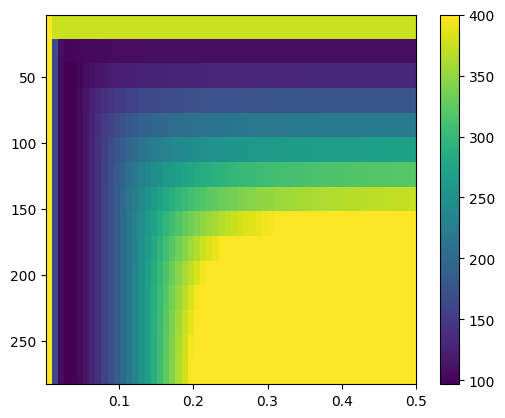

In [34]:
# Demo 2: Storing All Kernals = Local Inspection

#define the parameter ranges
krange = np.arange(3,303,20)
srange = np.linspace(0.001, 0.5, 60)

# initialise some output variables
sseMat = np.zeros((len(krange), len(srange)))
allkernels = [[0]*len(srange) for i in range(len(krange))]

# double loop over the two parameters
for ki in range(len(krange)):
  for si in range(len(srange)):
    #create a gaussian
    x  = np.arange(-krange[ki], krange[ki]+1)/srate
    gkern = np.exp(-x**2/(2*srange[si]**2))

    #filter the signal via convolution
    filtsig = np.convolve(noisysignal, gkern/sum(gkern), mode='same')

    # compute the SSE (Sum of Squared Errors)
    sseMat[ki,si] = np.sum((filtsig-signal)**2)

    allkernels[ki][si] = gkern


# plotting
plt.imshow(sseMat, vmax=400,
           extent=[srange[0],srange[-1],krange[-1],krange[0]])
plt.gca().set_aspect(1/plt.gca().get_data_ratio())
plt.colorbar()
plt.show()

In [35]:
# Extracting a Single Kernel = Direct Examination

allkernels[4][2]

array([1.66070266e-18, 4.42728722e-18, 1.16633081e-17, 3.03629547e-17,
       7.81096240e-17, 1.98565272e-16, 4.98815885e-16, 1.23827039e-15,
       3.03758846e-15, 7.36343762e-15, 1.76388604e-14, 4.17540556e-14,
       9.76708666e-14, 2.25771776e-13, 5.15718237e-13, 1.16410877e-12,
       2.59664673e-12, 5.72361491e-12, 1.24671211e-11, 2.68349123e-11,
       5.70784822e-11, 1.19972825e-10, 2.49190559e-10, 5.11468059e-10,
       1.03739388e-09, 2.07925178e-09, 4.11821212e-09, 8.06025117e-09,
       1.55893020e-08, 2.97949732e-08, 5.62726750e-08, 1.05024435e-07,
       1.93696324e-07, 3.53012950e-07, 6.35767214e-07, 1.13147210e-06,
       1.98988422e-06, 3.45819912e-06, 5.93896022e-06, 1.00788056e-05,
       1.69023058e-05, 2.80105137e-05, 4.58706004e-05, 7.42311191e-05,
       1.18706862e-04, 1.87587490e-04, 2.92934250e-04, 4.52037710e-04,
       6.89314497e-04, 1.03871975e-03, 1.54674101e-03, 2.27601461e-03,
       3.30956352e-03, 4.75559246e-03, 6.75268934e-03, 9.47517291e-03,
      

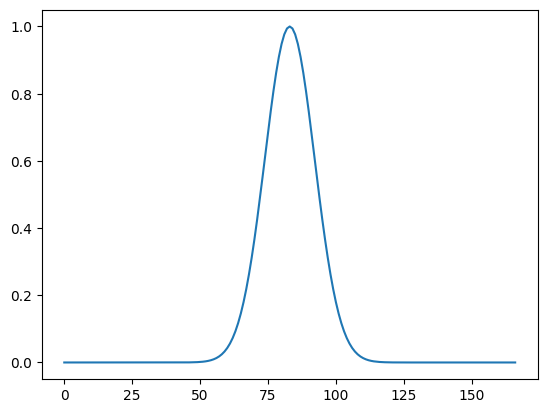

In [36]:
# Plotting a Single Kernel = Shape Visualisation

plt.plot(allkernels[4][2])

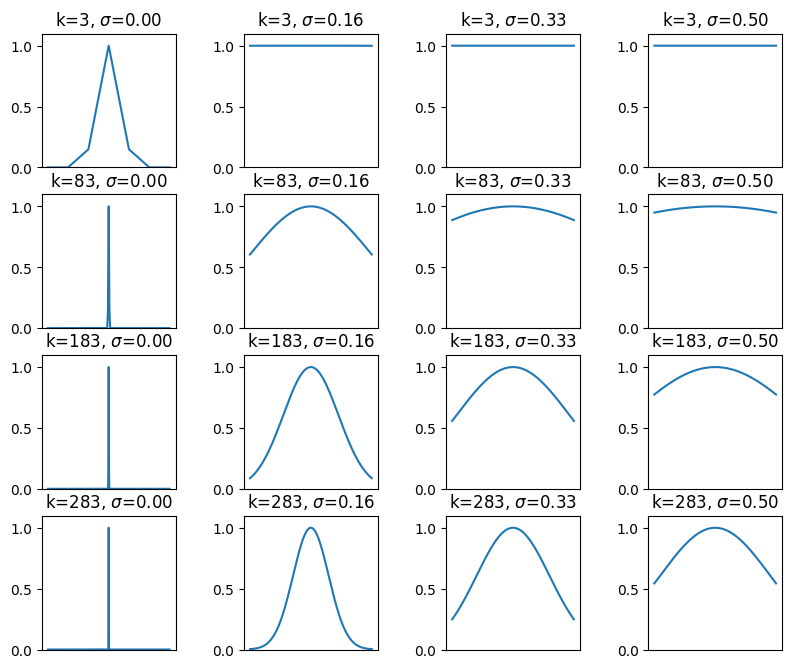

In [37]:
# Demo 3: Visualising Kernel Shapes = Initutive Understanding

fig, ax = plt.subplots(4,4,figsize=(10,8))

# Four equally spaced points on the grid
sidx = np.linspace(0,len(srange)-1,4).astype(int)
kidx = np.linspace(0,len(krange)-1,4).astype(int)

for si in range(4):
  for kj in range(4):
    ax[kj,si].plot(allkernels[kidx[kj]][sidx[si]])
    ax[kj,si].set_xticks([])
    ax[kj,si].set_ylim([0,1.1])
    ax[kj,si].set_title('k=%g, $\\sigma$=%.2f'%(krange[kidx[kj]], srange[sidx[si]]))
    ax[kj,si].set_aspect(1/ax[kj,si].get_data_ratio())

plt.show()
